# M3_01 — Walk-forward splits 1D + holdout final

Objetivo (M3):
- Definir una política de validación temporal reproducible (walk-forward) + holdout final.
- Exportar un archivo de splits reutilizable por notebooks de experimentos.

Outputs:
- `../data/_splits/splits_1d_walkforward_v1.json`
- `../data/_splits/splits_1d_walkforward_v1.png`


In [1]:
import sys
import subprocess
import importlib
import pathlib
import json
from datetime import datetime, timezone

for p in ["pandas", "numpy"]:
    try:
        importlib.import_module(p)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", p])

try:
    importlib.import_module("matplotlib")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [2]:
base_dir = pathlib.Path(".").resolve()
data_dir = (base_dir.parent / "data").resolve()
splits_dir = (data_dir / "_splits").resolve()
splits_dir.mkdir(parents=True, exist_ok=True)

DATASET_PATH = data_dir / "btc_1d_features__macro.csv"
TIMESTAMP_COL = "timestamp"

TRAIN_START_MODE = "start_of_data"
HOLDOUT_START_DATE = "2025-06-01"
VAL_YEARS = [2020, 2021, 2022, 2023, 2024]
HOLDOUT_END_YEAR = 2026

SPLITS_PATH = splits_dir / "splits_1d_walkforward_v3_holdout_from_2025_06.json"
FIG_PATH = splits_dir / "splits_1d_walkforward_v3_holdout_from_2025_06.png"

(DATASET_PATH.as_posix(), SPLITS_PATH.name, FIG_PATH.name)

('/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/proyecto_grado/data/btc_1d_features__macro.csv',
 'splits_1d_walkforward_v3_holdout_from_2025_06.json',
 'splits_1d_walkforward_v3_holdout_from_2025_06.png')

In [3]:
df = pd.read_csv(DATASET_PATH)
df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], utc=True)
df = df.sort_values(TIMESTAMP_COL).reset_index(drop=True)

ts_min = df[TIMESTAMP_COL].min()
ts_max = df[TIMESTAMP_COL].max()

(len(df), ts_min.isoformat(), ts_max.isoformat())

(4144, '2014-11-10T00:00:00+00:00', '2026-03-15T00:00:00+00:00')

In [4]:
def year_range(year: int):
    start = pd.Timestamp(year=year, month=1, day=1, tz="UTC")
    end = pd.Timestamp(year=year + 1, month=1, day=1, tz="UTC") - pd.Timedelta(seconds=1)
    return start, end


def clip_to_data(start: pd.Timestamp, end: pd.Timestamp, ts_min: pd.Timestamp, ts_max: pd.Timestamp):
    start2 = max(start, ts_min)
    end2 = min(end, ts_max)
    return start2, end2


def count_in_window(df: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp):
    m = (df[TIMESTAMP_COL] >= start) & (df[TIMESTAMP_COL] <= end)
    return int(m.sum())


folds = []
for val_year in VAL_YEARS:
    if TRAIN_START_MODE == "start_of_data":
        train_start = ts_min
    else:
        train_start = pd.Timestamp(str(TRAIN_START_MODE), tz="UTC")
    train_end = pd.Timestamp(year=val_year, month=1, day=1, tz="UTC") - pd.Timedelta(seconds=1)
    val_start, val_end = year_range(val_year)

    train_start, train_end = clip_to_data(train_start, train_end, ts_min, ts_max)
    val_start, val_end = clip_to_data(val_start, val_end, ts_min, ts_max)

    fold = {
        "val_year": int(val_year),
        "train": {
            "start": train_start.isoformat(),
            "end": train_end.isoformat(),
            "rows": count_in_window(df, train_start, train_end),
        },
        "val": {
            "start": val_start.isoformat(),
            "end": val_end.isoformat(),
            "rows": count_in_window(df, val_start, val_end),
        },
    }
    folds.append(fold)

holdout_start = pd.Timestamp(HOLDOUT_START_DATE, tz="UTC")
holdout_end = pd.Timestamp(year=HOLDOUT_END_YEAR + 1, month=1, day=1, tz="UTC") - pd.Timedelta(seconds=1)
holdout_start, holdout_end = clip_to_data(holdout_start, holdout_end, ts_min, ts_max)

splits = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "dataset_path": DATASET_PATH.as_posix(),
    "train_start_mode": TRAIN_START_MODE,
    "holdout_start_date": HOLDOUT_START_DATE,
    "timestamp_col": TIMESTAMP_COL,
    "data_range": {"start": ts_min.isoformat(), "end": ts_max.isoformat(), "rows": int(len(df))},
    "walk_forward_folds": folds,
    "final_holdout": {
        "start": holdout_start.isoformat(),
        "end": holdout_end.isoformat(),
        "rows": count_in_window(df, holdout_start, holdout_end),
    },
}

SPLITS_PATH.write_text(json.dumps(splits, ensure_ascii=False, indent=2), encoding="utf-8")
SPLITS_PATH.as_posix()

'/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/proyecto_grado/data/_splits/splits_1d_walkforward_v3_holdout_from_2025_06.json'

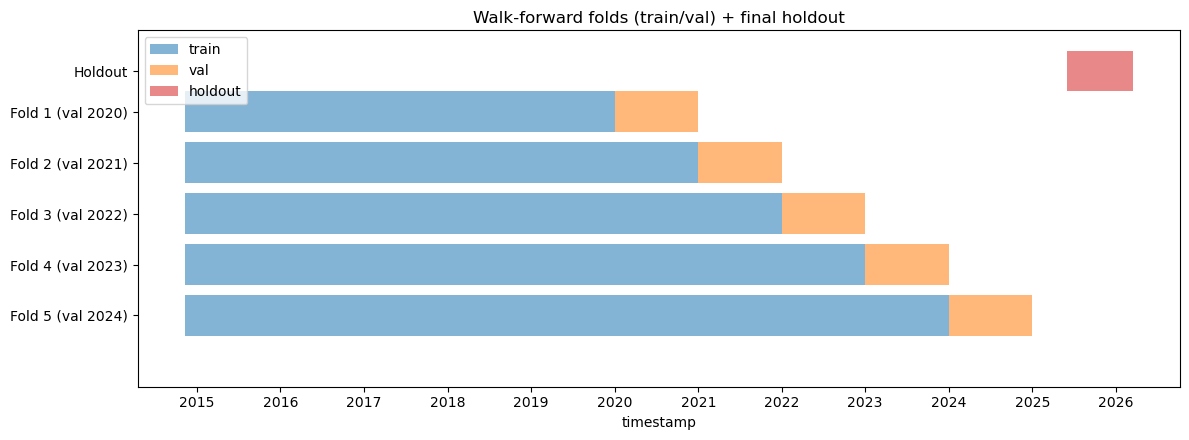

'/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/proyecto_grado/data/_splits/splits_1d_walkforward_v3_holdout_from_2025_06.png'

In [5]:
folds = splits["walk_forward_folds"]
n_folds = len(folds)

fig_h = 0.55 * (n_folds + 1) + 1.2
fig, ax = plt.subplots(figsize=(12, fig_h))

def to_num(ts):
    return mdates.date2num(pd.to_datetime(ts, utc=True).to_pydatetime())

legend_added = set()

def draw_bar(start_iso, end_iso, y, color, label):
    start = pd.to_datetime(start_iso, utc=True)
    end = pd.to_datetime(end_iso, utc=True)
    left = to_num(start)
    width = to_num(end) - to_num(start)
    use_label = label if label not in legend_added else None
    ax.broken_barh([(left, width)], (y, 0.8), facecolors=color, alpha=0.55, label=use_label)
    if use_label:
        legend_added.add(label)

y_labels = []
y_ticks = []
for i, fold in enumerate(folds, start=1):
    y = (n_folds - i + 1) * 1.0
    y_ticks.append(y + 0.4)
    y_labels.append(f"Fold {i} (val {fold['val_year']})")
    draw_bar(fold["train"]["start"], fold["train"]["end"], y, "#1f77b4", "train")
    draw_bar(fold["val"]["start"], fold["val"]["end"], y, "#ff7f0e", "val")

y_holdout = (n_folds + 0.8) * 1.0
y_ticks.append(y_holdout + 0.4)
y_labels.append("Holdout")
draw_bar(splits["final_holdout"]["start"], splits["final_holdout"]["end"], y_holdout, "#d62728", "holdout")

ax.set_ylim(0, y_holdout + 1.2)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("timestamp")
ax.set_title("Walk-forward folds (train/val) + final holdout")
ax.legend(loc="upper left")
plt.tight_layout()
fig.savefig(FIG_PATH, dpi=200)
plt.show()
FIG_PATH.as_posix()